### 1 Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time

In [2]:
train = pd.read_csv('../data/raw/train.csv',dtype={'StateHoliday':'string'})
test = pd.read_csv('../data/raw/test.csv',dtype={'StateHoliday':'string'})
store = pd.read_csv('../data/raw/store.csv')
display(train.head(),test.head(),store.head())
print(train.shape,test.shape,store.shape)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


(1017209, 9) (41088, 8) (1115, 10)


### 2 Null Data

#### 2.1 Train Data

In [3]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

#### 2.2 Test Data

In [4]:
test.isnull().sum()

Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

In [5]:
cond = test['Open'].isnull()
test[cond]

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
479,480,622,4,2015-09-17,NaN,1,0,0
1335,1336,622,3,2015-09-16,NaN,1,0,0
2191,2192,622,2,2015-09-15,NaN,1,0,0
3047,3048,622,1,2015-09-14,NaN,1,0,0
4759,4760,622,6,2015-09-12,NaN,0,0,0
5615,5616,622,5,2015-09-11,NaN,0,0,0
6471,6472,622,4,2015-09-10,NaN,0,0,0
7327,7328,622,3,2015-09-09,NaN,0,0,0
8183,8184,622,2,2015-09-08,NaN,0,0,0
9039,9040,622,1,2015-09-07,NaN,0,0,0


In [6]:
cond = train['Store'] == 622
df = train[cond]
df.sort_values(by = 'Date').iloc[-20:]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
21806,622,7,2015-07-12,0,0,0,0,0,0
20691,622,1,2015-07-13,6349,535,1,1,0,0
19576,622,2,2015-07-14,5102,439,1,1,0,0
18461,622,3,2015-07-15,4718,434,1,1,0,0
17346,622,4,2015-07-16,5615,494,1,1,0,0
16231,622,5,2015-07-17,5263,462,1,1,0,0
15116,622,6,2015-07-18,2367,265,1,0,0,0
14001,622,7,2015-07-19,0,0,0,0,0,0
12886,622,1,2015-07-20,4688,429,1,0,0,1
11771,622,2,2015-07-21,3529,367,1,0,0,1


In [7]:
test.fillna(1,inplace=True)
test.isnull().sum()

Id               0
Store            0
DayOfWeek        0
Date             0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

#### 2.3 Store Data

In [8]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [9]:
v1 = 'CompetitionDistance'
v2 = 'CompetitionOpenSinceMonth'
v3 = 'CompetitionOpenSinceYear'
v4 = 'Promo2SinceWeek'
v5 = 'Promo2SinceYear'
v6 = 'PromoInterval'

In [10]:
# v2 and v3 are null for the same samples
store[(store[v2].isnull() & store[v3].isnull())].shape

(354, 10)

In [11]:
# v4,v5 and v6 are null for the same samples
print(store[store[v4].isnull()&store[v5].isnull()&store[v6].isnull()].shape)
store[store[v4].isnull()&store[v5].isnull()&store[v6].isnull()&(store['Promo2']==0)].shape

(544, 10)


(544, 10)

In [12]:
store.dtypes


Store                          int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object

In [ ]:
store = store.fillna(0)
store.isnull().sum()

#### 2.4 Sales and Date Relationship

In [14]:
cond = train['Sales'] > 0 
sales_data = train[cond]

<Axes: xlabel='Date'>

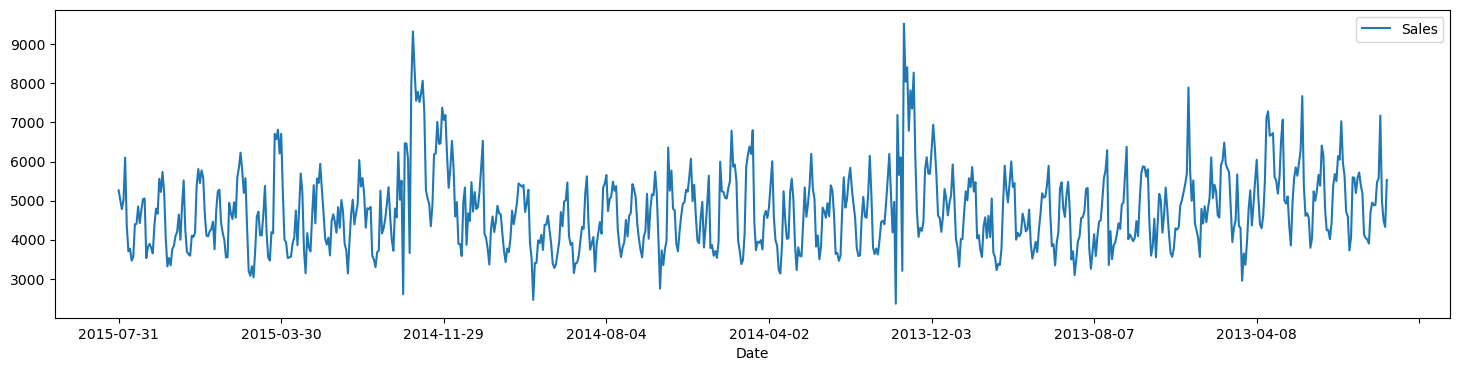

In [15]:
sales_data.loc[train['Store'] == 1].plot(x = 'Date', y ='Sales', figsize=(18,4))

In [16]:
test['Date'].unique() #predict the salescondition of 2015 Aug to Sep

<StringArray>
['2015-09-17', '2015-09-16', '2015-09-15', '2015-09-14', '2015-09-13',
 '2015-09-12', '2015-09-11', '2015-09-10', '2015-09-09', '2015-09-08',
 '2015-09-07', '2015-09-06', '2015-09-05', '2015-09-04', '2015-09-03',
 '2015-09-02', '2015-09-01', '2015-08-31', '2015-08-30', '2015-08-29',
 '2015-08-28', '2015-08-27', '2015-08-26', '2015-08-25', '2015-08-24',
 '2015-08-23', '2015-08-22', '2015-08-21', '2015-08-20', '2015-08-19',
 '2015-08-18', '2015-08-17', '2015-08-16', '2015-08-15', '2015-08-14',
 '2015-08-13', '2015-08-12', '2015-08-11', '2015-08-10', '2015-08-09',
 '2015-08-08', '2015-08-07', '2015-08-06', '2015-08-05', '2015-08-04',
 '2015-08-03', '2015-08-02', '2015-08-01']
Length: 48, dtype: str

Use 2015 June to July data as validation dataset

Divide train.csv data into two datasets

### 3 Combine Dataset

In [17]:
display(train.shape, test.shape)
cond = train['Sales'] > 0
train = train[cond]

train = pd.merge(train, store, on='Store', how='left')
test = pd.merge(test, store, on='Store', how ='left')
display(train.shape,test.shape)

(1017209, 9)

(41088, 8)

(844338, 18)

(41088, 17)

In [19]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844338 non-null  int64  
 1   DayOfWeek                  844338 non-null  int64  
 2   Date                       844338 non-null  str    
 3   Sales                      844338 non-null  int64  
 4   Customers                  844338 non-null  int64  
 5   Open                       844338 non-null  int64  
 6   Promo                      844338 non-null  int64  
 7   StateHoliday               844338 non-null  string 
 8   SchoolHoliday              844338 non-null  int64  
 9   StoreType                  844338 non-null  str    
 10  Assortment                 844338 non-null  str    
 11  CompetitionDistance        844338 non-null  float64
 12  CompetitionOpenSinceMonth  844338 non-null  float64
 13  CompetitionOpenSinceYear   844338 non-nu

In [20]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Id                         41088 non-null  int64  
 1   Store                      41088 non-null  int64  
 2   DayOfWeek                  41088 non-null  int64  
 3   Date                       41088 non-null  str    
 4   Open                       41088 non-null  float64
 5   Promo                      41088 non-null  int64  
 6   StateHoliday               41088 non-null  string 
 7   SchoolHoliday              41088 non-null  int64  
 8   StoreType                  41088 non-null  str    
 9   Assortment                 41088 non-null  str    
 10  CompetitionDistance        41088 non-null  float64
 11  CompetitionOpenSinceMonth  41088 non-null  float64
 12  CompetitionOpenSinceYear   41088 non-null  float64
 13  Promo2                     41088 non-null  int64  
 14  P

### 4 Feature Engineering

In [22]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [31]:
train['StateHoliday'].unique()

<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: string

In [25]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,0.0,0.0,0
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,0.0,0.0,0
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,0.0,0.0,0


In [47]:
%%time

for data in [train,test]:

    # Change 'Date'
    data['year'] = data['Date'].apply(lambda x:x.split('-')[0]).astype(int)
    data['month'] = data['Date'].apply(lambda x:x.split('-')[1]).astype(int)
    data['day'] = data['Date'].apply(lambda x:x.split('-')[2]).astype(int)

    # PromoInterval is string 
    month2str = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul',
                 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    data['monthstr'] = data['month'].map(month2str)

    # convert function
    convert = lambda x: 0 if x['PromoInterval'] == 0 else 1 if x['monthstr'] in x ['PromoInterval'] else 0
    data['IsPromoMonth'] = data.apply(convert, axis = 1)

    # StoreType, Assortment and StateHoliday from String to Int
    mappings = {'0':0, 'a':1, 'b':2, 'c':3, 'd':4}
    data['StoreType'] = data['StoreType'].replace(mappings).astype(int)
    data['Assortment'] = data['Assortment'].replace(mappings).astype(int)
    data['StateHoliday'] = data['StateHoliday'].replace(mappings).astype(int)


CPU times: total: 4.72 s
Wall time: 4.84 s


In [48]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,monthstr,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,3,...,2008.0,0,0.0,0.0,0,2015,7,31,Jul,0
1,2,5,2015-07-31,6064,625,1,1,0,1,1,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,Jul,1
2,3,5,2015-07-31,8314,821,1,1,0,1,1,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,Jul,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,3,...,2009.0,0,0.0,0.0,0,2015,7,31,Jul,0
4,5,5,2015-07-31,4822,559,1,1,0,1,1,...,2015.0,0,0.0,0.0,0,2015,7,31,Jul,0


In [49]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844338 non-null  int64  
 1   DayOfWeek                  844338 non-null  int64  
 2   Date                       844338 non-null  str    
 3   Sales                      844338 non-null  int64  
 4   Customers                  844338 non-null  int64  
 5   Open                       844338 non-null  int64  
 6   Promo                      844338 non-null  int64  
 7   StateHoliday               844338 non-null  int64  
 8   SchoolHoliday              844338 non-null  int64  
 9   StoreType                  844338 non-null  int64  
 10  Assortment                 844338 non-null  int64  
 11  CompetitionDistance        844338 non-null  float64
 12  CompetitionOpenSinceMonth  844338 non-null  float64
 13  CompetitionOpenSinceYear   844338 non-nu

### 5 Train and Test Dataset

In [54]:
display(train.shape, test.shape)
df_train = train.drop(['Date','monthstr','PromoInterval','Customers','Open'], axis = 1)
df_test = test.drop(['Date', 'monthstr', 'PromoInterval', 'Id', 'Open'], axis = 1)
display(df_train.shape, df_test.shape)

(844338, 23)

(41088, 22)

(844338, 18)

(41088, 17)

In [58]:
# Split train dataset into train and validation datasets

X_val = df_train[:6*7*1115]
X_train = df_train[6*7*1115:]

### 6 Relative Coefficient

<Axes: >

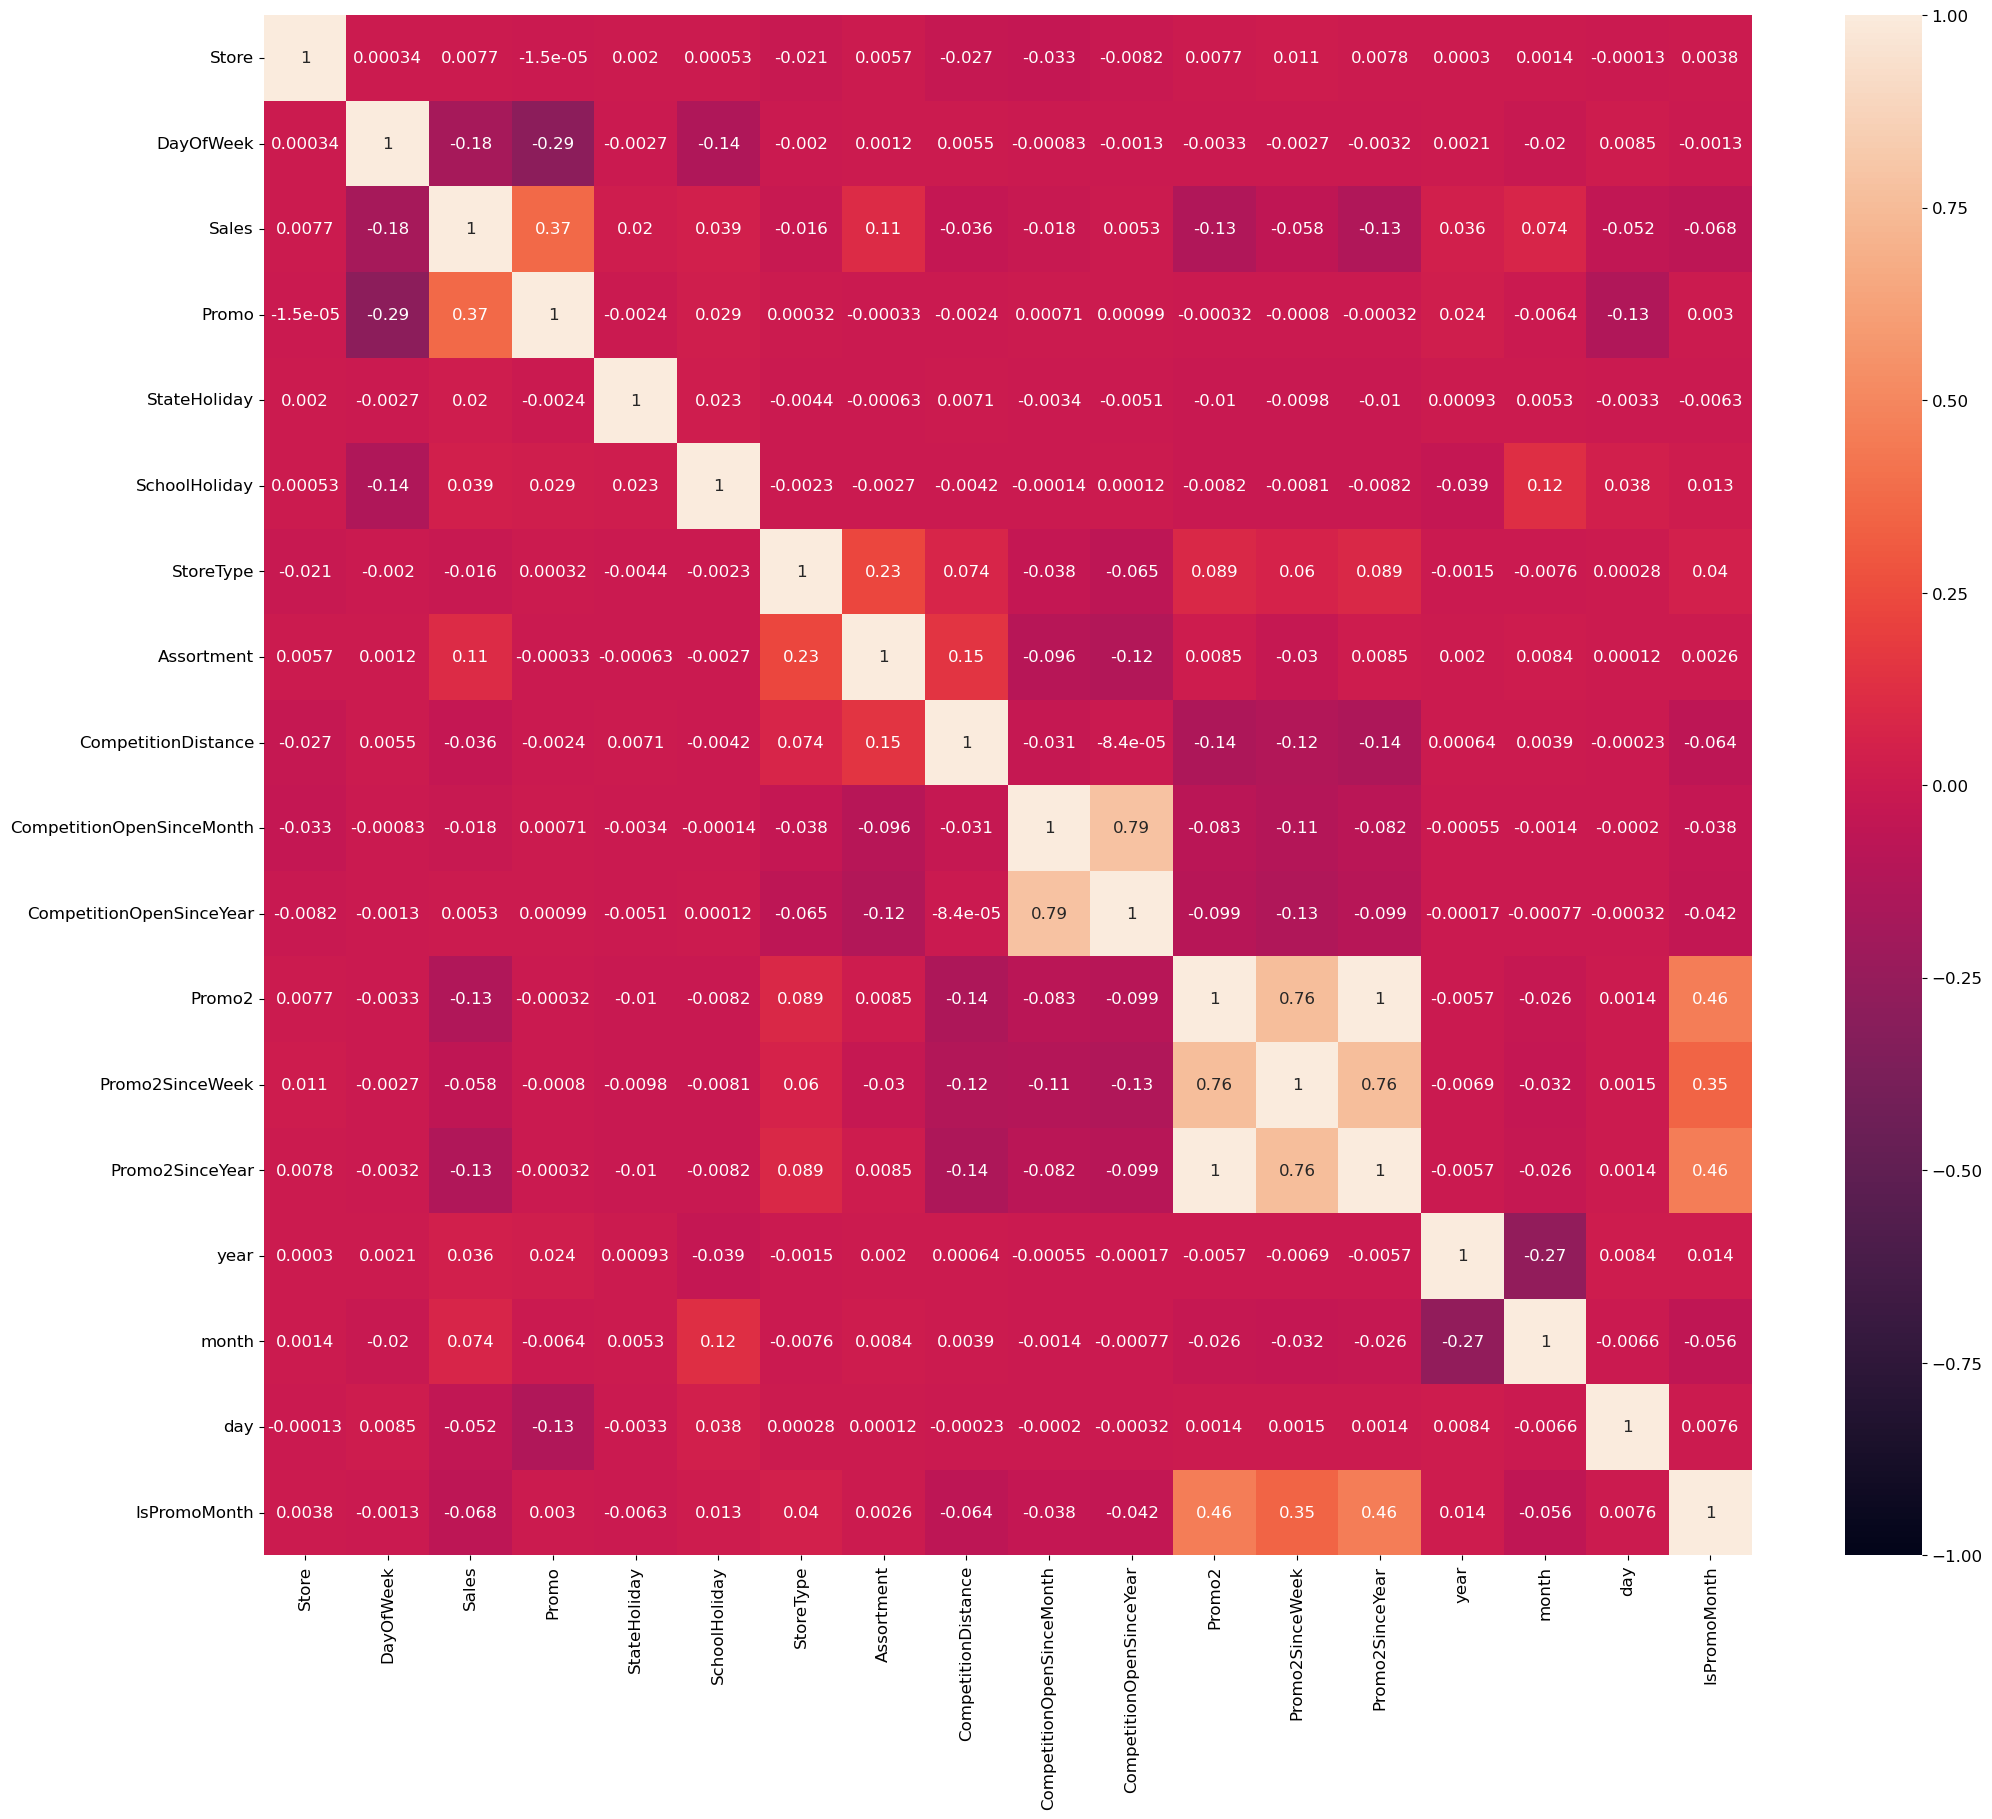

In [59]:
plt.figure(figsize=(24,20))

plt.rcParams['font.size'] = 12

sns.heatmap(df_train.corr(), annot=True, vmin=-1,vmax=1)


### 7 Extract Training Data

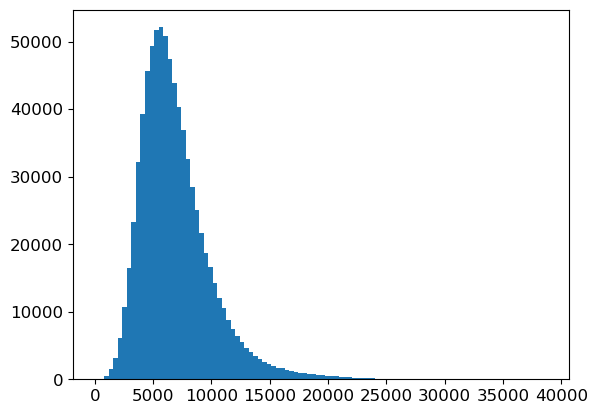

In [64]:
_ = plt.hist(X_train['Sales'], bins = 100)

In [65]:
y_train = np.log1p(X_train['Sales'])
y_val  = np.log1p(X_val['Sales'])

X_train = X_train.drop('Sales', axis = 1)
X_val = X_val.drop('Sales', axis = 1)


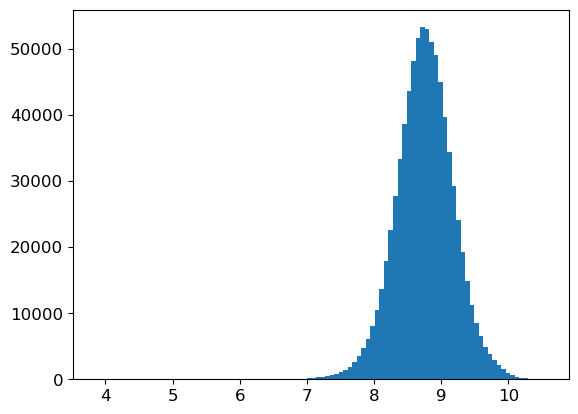

In [67]:
_ = plt.hist(y_train, bins = 100)

### 8 Model

#### 8.1 Evaluation Metrics

In [74]:
# RMSPE

def rmspe(y, yhat):
    return np.sqrt(np.mean((1-yhat/y)**2))

In [75]:
def rmspe_xg(y, yhat):
    y = np.expm1(y) # np.exp(2)-1
    yhat = np.expm1(yhat.get_label())
    return 'rmspe',rmspe(y,yhat)

#### 8.2 Model Train

In [76]:
%%time
params = {'objective': 'reg:squarederror',
          'booster':'gbtree',
          'eta':0.03,
          'max_depth':10,
          'subsample':0.9,
          'colsample_bytree':0.7,
          'verbosity': 1, 
          'seed':10}

num_boost_round = 6000

dtrain = xgb.DMatrix(X_train, y_train)
dval   = xgb.DMatrix(X_val, y_val)

print('Start training ...')

evals = [(dtrain, 'train'), (dval, 'validation')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=100,
    custom_metric=rmspe_xg,
    verbose_eval=True
)


Start training ...
[0]	train-rmse:0.42119	train-rmspe:0.49100	validation-rmse:0.41271	validation-rmspe:0.49566
[1]	train-rmse:0.41603	train-rmspe:0.48293	validation-rmse:0.40769	validation-rmspe:0.48789
[2]	train-rmse:0.41104	train-rmspe:0.47575	validation-rmse:0.40236	validation-rmspe:0.47996
[3]	train-rmse:0.40547	train-rmspe:0.46705	validation-rmse:0.39662	validation-rmspe:0.47071
[4]	train-rmse:0.40033	train-rmspe:0.45921	validation-rmse:0.39158	validation-rmspe:0.46309
[5]	train-rmse:0.39615	train-rmspe:0.45359	validation-rmse:0.38716	validation-rmspe:0.45667
[6]	train-rmse:0.39149	train-rmspe:0.44691	validation-rmse:0.38238	validation-rmspe:0.44961
[7]	train-rmse:0.38710	train-rmspe:0.44034	validation-rmse:0.37810	validation-rmspe:0.44329
[8]	train-rmse:0.38256	train-rmspe:0.43370	validation-rmse:0.37334	validation-rmspe:0.43604
[9]	train-rmse:0.37849	train-rmspe:0.42772	validation-rmse:0.36940	validation-rmspe:0.43016
[10]	train-rmse:0.37610	train-rmspe:0.42383	validation-rmse:0

In [ ]:
model.save_model('./train_model.json')

#### 8.3 Model Validation

In [94]:
print('validation data performance:')
X_val.sort_index()
y_val.sort_index()

yhat = model.predict(xgb.DMatrix(X_val))
error = rmspe(np.expm1(y_val),np.expm1(yhat))
print('rmspe:',error)

validation data performance:
rmspe: 0.12798722791673564


In [96]:
res = pd.DataFrame(data=y_val)
res['Prediction']=yhat

res = pd.merge(X_val,res,left_index=True,right_index=True)
res['Ratio'] = res['Prediction']/res['Sales']
res['Error'] = abs(1-res['Ratio'])
res['weight'] = res['Sales']/res['Prediction']
display(res.head())

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,...,Promo2SinceYear,year,month,day,IsPromoMonth,Sales,Prediction,Ratio,Error,weight
0,1,5,1,0,1,3,1,1270.0,9.0,2008.0,...,0.0,2015,7,31,0,8.568646,8.582921,1.001666,0.001666,0.998337
1,2,5,1,0,1,1,1,570.0,11.0,2007.0,...,2010.0,2015,7,31,1,8.710290,8.671113,0.995502,0.004498,1.004518
2,3,5,1,0,1,1,1,14130.0,12.0,2006.0,...,2011.0,2015,7,31,1,9.025816,9.048903,1.002558,0.002558,0.997449
3,4,5,1,0,1,3,3,620.0,9.0,2009.0,...,0.0,2015,7,31,0,9.546527,9.434479,0.988263,0.011737,1.011876
4,5,5,1,0,1,1,1,29910.0,4.0,2015.0,...,0.0,2015,7,31,0,8.481151,8.636518,1.018319,0.018319,0.982010


comparison between prediction and real is 1.0011


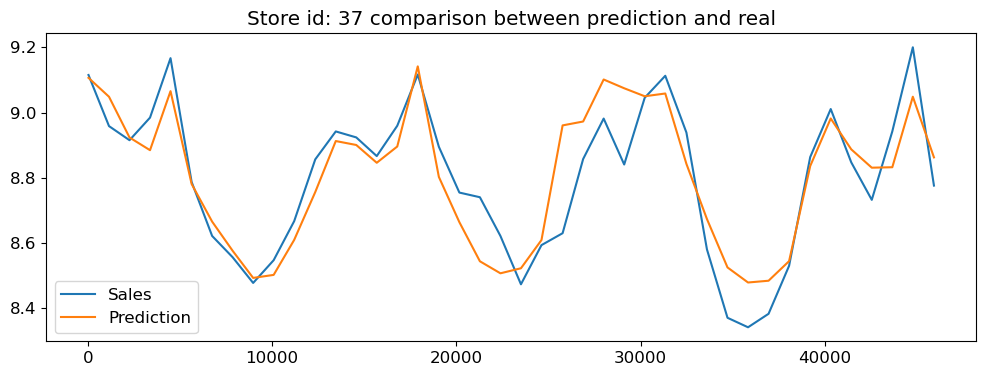

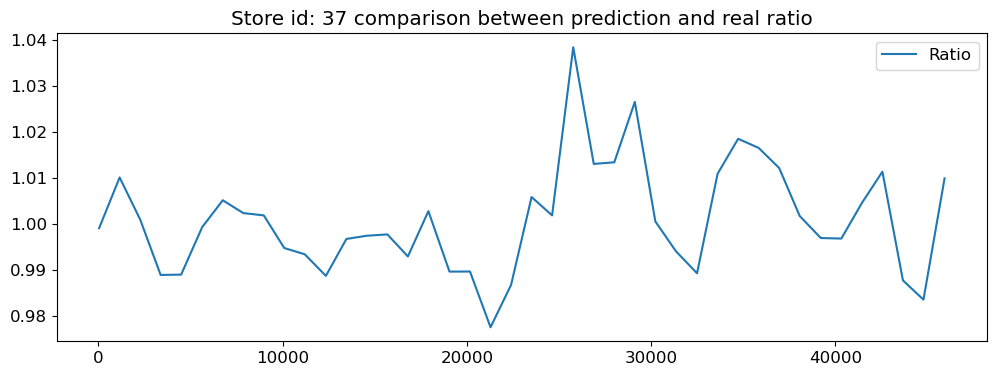

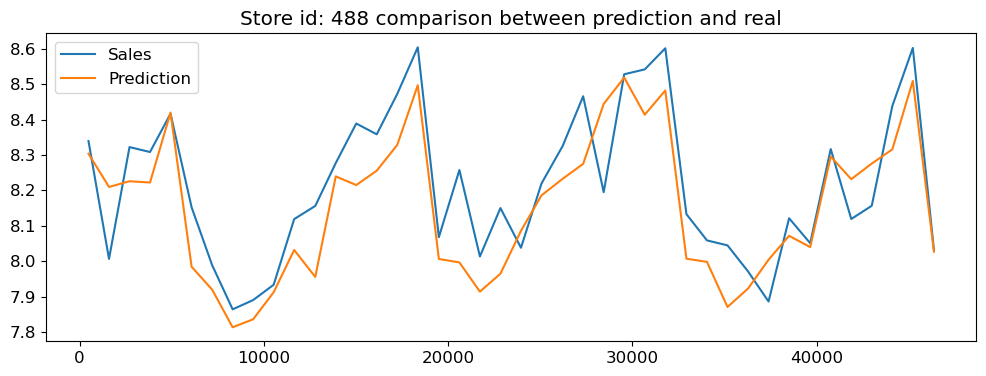

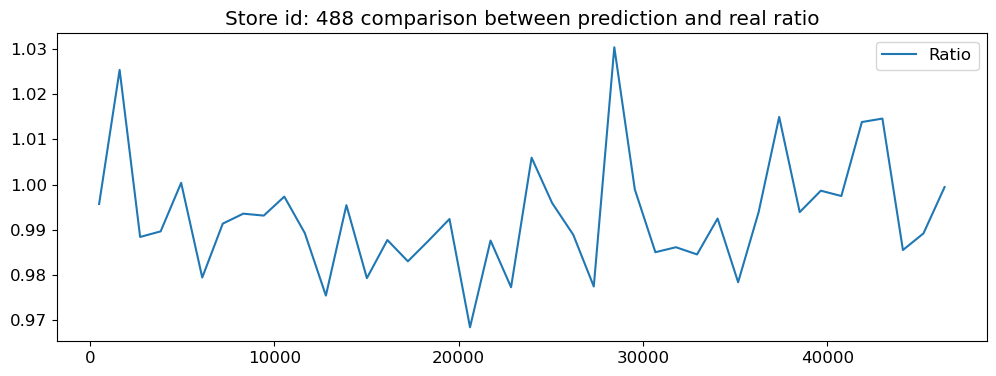

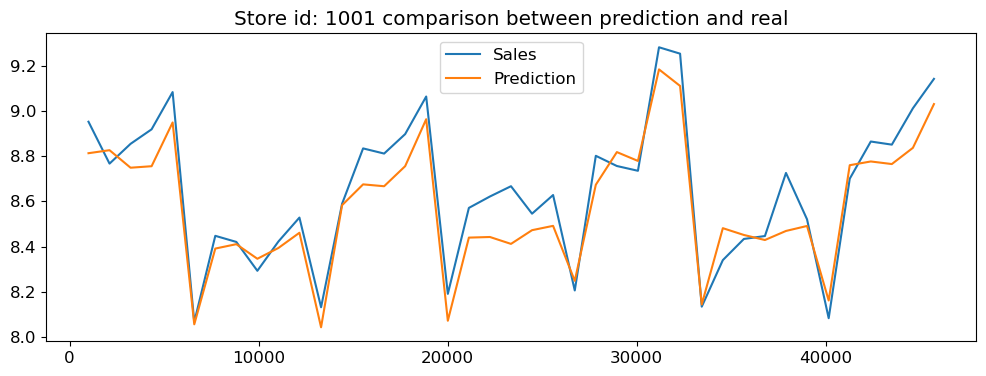

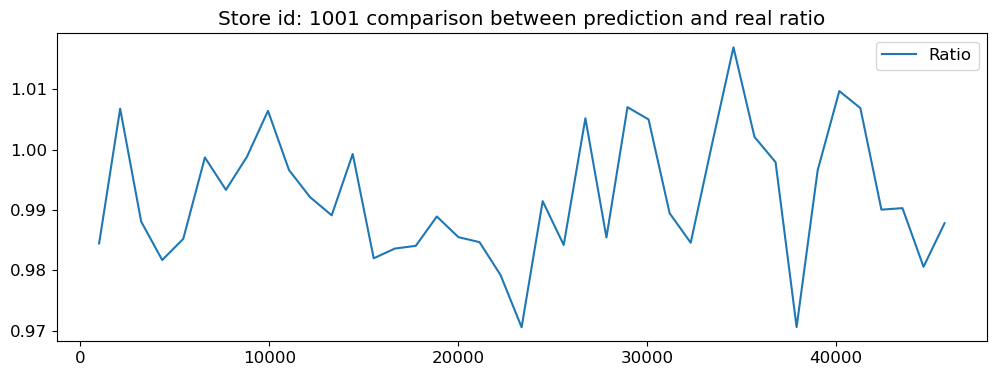

In [97]:
col_1 = ['Sales','Prediction']
col_2 = ['Ratio']

# Pick 3 shops for visualization
shops = np.random.randint(1,1116,size=3)

print('comparison between prediction and real is %0.4f' %(res['Ratio'].mean()))
for shop in shops:
    cond = res['Store'] == shop
    df1 = pd.DataFrame(data = res[cond], columns = col_1)
    df2 = pd.DataFrame(data = res[cond], columns = col_2)
    df1.plot(title= 'Store id: %d comparison between prediction and real' % (shop),figsize = (12,4))
    df2.plot(title= 'Store id: %d comparison between prediction and real ratio' % (shop),figsize = (12,4))


In [100]:
res.sort_values(by = ['Error'],ascending=False)

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,...,Promo2SinceYear,year,month,day,IsPromoMonth,Sales,Prediction,Ratio,Error,weight
20419,292,5,0,0,0,1,1,1100.0,6.0,2009.0,...,0.0,2015,7,10,0,6.920672,8.531446,1.232748,2.327484e-01,0.811196
34346,782,5,0,0,0,3,3,5390.0,8.0,2003.0,...,2012.0,2015,6,26,0,7.260523,8.567621,1.180028,1.800282e-01,0.847437
29981,909,3,1,0,0,1,3,1680.0,0.0,0.0,...,2009.0,2015,7,1,0,8.174139,9.585114,1.172614,1.726144e-01,0.852795
38929,909,1,0,0,0,1,3,1680.0,0.0,0.0,...,2009.0,2015,6,22,0,10.634701,9.189311,0.864087,1.359126e-01,1.157290
26606,876,6,0,0,0,1,1,21790.0,4.0,2005.0,...,2015.0,2015,7,4,0,9.596215,8.352155,0.870359,1.296407e-01,1.148951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,598,3,0,0,0,3,1,550.0,12.0,2013.0,...,2014.0,2015,7,22,1,8.494334,8.494339,1.000001,5.994570e-07,0.999999
17504,749,2,1,0,0,1,1,3410.0,8.0,2011.0,...,2015.0,2015,7,14,1,8.728426,8.728431,1.000001,5.334617e-07,0.999999
2483,258,3,1,0,0,1,1,27190.0,7.0,2010.0,...,2009.0,2015,7,29,1,8.779250,8.779245,1.000000,4.943067e-07,1.000000
9537,603,3,0,0,0,1,1,340.0,4.0,2007.0,...,2010.0,2015,7,22,1,8.659560,8.659563,1.000000,3.039267e-07,1.000000


#### 8.4 Model Optimization

##### 8.4.1 Overall Model Optimizataion

7 0.12432104110479758
0.997


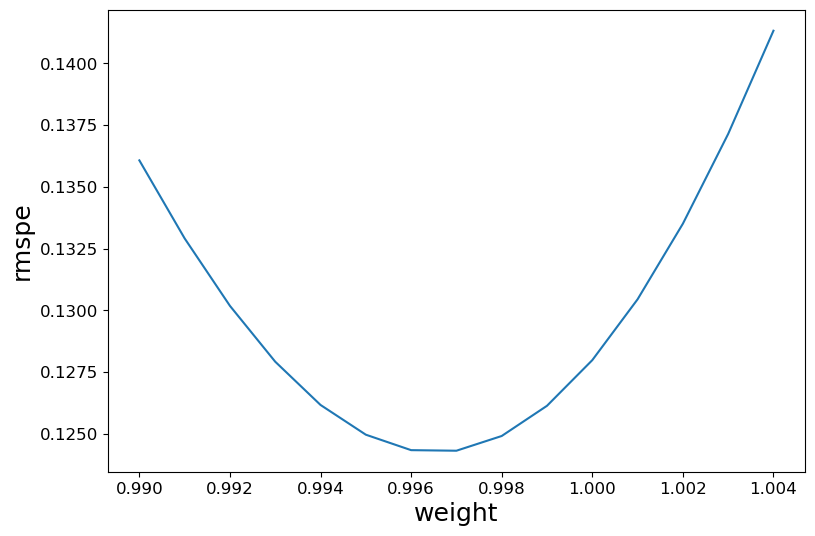

In [112]:
weights = [(0.99+(i/1000)) for i in range(15)]

errors = []
for w in weights:
    error = rmspe(np.expm1(y_val),np.expm1(yhat*w))
    errors.append(error)

errors = pd.Series(errors, index=weights)
plt.figure(figsize=(9,6))
errors.plot()

plt.xlabel('weight',fontsize = 18)
plt.ylabel('rmspe', fontsize = 18)

index=errors.argmin()
print(index, errors.min())
print(weights[index])
 

##### 8.4.2 Consider Various Stores

In [113]:
y_val.shape

(46830,)

In [114]:
df_test.shape

(41088, 17)

In [ ]:
shops = np.arange(1,1116)
weights1 = [] # validation weights
weights2 = [] # test weights

for shop in shops:
    cond = res['Store'] == shop
    df1 = pd.DataFrame(res[cond], columns = col_1)
    cond2 = df_test['Store'] == shop
    df2 = pd.DataFrame(df_test[cond2])
    weights = [(0.98+(i/1000)) for i in range(40)]
    errors = []
    for w in weights:
        error = rmspe(np.expm1(df1['Sales']),np.expm1(df1['Prediction']*w))
        errors.append(error)
    errors = pd.Series(errors, index = weights)
    index = errors.argmin()
    
    best_weight = np.array(weights[index])
    weights1.extend(best_weight.repeat(len(df1)).tolist())
    weights2.extend(best_weight.repeat(len(df2)).tolist())

X_val = X_val.sort_values(by='Store')
X_val['weights1'] = weights1
X_val = X_val.sort_index()

weights1 = X_val['weights1']
